# 演習3. パイプラインを組んで、速くする

部品はそろいました。あとは**どう組むか**です。この演習で決めるのは2つ。

- **キューの容量をいくつにするか**（3-1）
- **段をどう分け、各段に何人置くか**（3-2）

## 3-1. 【予測クイズ】容量を変えると、速くなるか

作る側と使う側をキューでつなぎ、**データを 60個流します。**
測るのは「60個を流し終えるまでの速さ」で、**FPS（＝ 60個 ÷ かかった秒数）**で表示します。

設定は2つです。

- **【A】** 作る側 いつも 10ms/個、使う側 50ms/個（ばらつきなし）
- **【B】** 作る側 ふだん 10ms、**5個に1回だけ 90ms**（平均 26ms/個）、使う側 30ms/個

**B は平均で見れば作る側のほうが速い**（26ms < 30ms）ことに注意してください。

キューの容量（`capacity`）は `ConcurrentQueue<T> q(capacity);` に渡した値で、**この値を変えて測ります。**

どちらの設定も、上限を決めているのは**使う側**です。
A なら 1個 50ms なので理想は 20.0 FPS、B なら 1個 30ms なので理想は 33.3 FPS。

**実行前に予測してください。** 容量を大きくすると `FPS` はどうなるでしょうか。

> 下の2つのセルで、キュー（`cq.h`）とプログラム本体をファイルに書き出します。
> **コンパイルと実行は、その次のセル**です。

In [ ]:
%%writefile cq.h
// ============================================================
//  cq.h ―― この演習で使うスレッドセーフなキュー
//  中身は読まなくてよい。使うのは push / pop / size の3つだけ。
// ============================================================
#pragma once
#include <queue>
#include <mutex>
#include <condition_variable>

template <typename T>
class ConcurrentQueue {
public:
    explicit ConcurrentQueue(std::size_t capacity) : capacity_(capacity) {}

    // 入れる。満杯なら空くまで待つ
    void push(const T& v) {
        std::unique_lock<std::mutex> lk(mtx_);
        can_push_.wait(lk, [this] { return q_.size() < capacity_; });
        q_.push(v);
        if (q_.size() > peak_) peak_ = q_.size();
        lk.unlock();
        can_pop_.notify_one();
    }

    // 取り出す。空なら来るまで待つ（失敗しない）
    T pop() {
        std::unique_lock<std::mutex> lk(mtx_);
        can_pop_.wait(lk, [this] { return !q_.empty(); });
        T v = q_.front(); q_.pop();
        lk.unlock();
        can_push_.notify_one();
        return v;
    }

    std::size_t size() const { std::lock_guard<std::mutex> g(mtx_); return q_.size(); }
    std::size_t peak() const { std::lock_guard<std::mutex> g(mtx_); return peak_; }   // 観測用：並んだ最大数

private:
    std::queue<T> q_;
    std::size_t capacity_;
    std::size_t peak_ = 0;
    mutable std::mutex mtx_;
    std::condition_variable can_pop_;    // 「取り出せるようになった」
    std::condition_variable can_push_;   // 「入れられるようになった」
};

In [ ]:
%%writefile ex03a.cpp
#include <iostream>
#include <iomanip>
#include <thread>
#include <chrono>
#include "cq.h"
using namespace std::chrono;

const int N = 60;                                // 流すデータの個数
void wait_ms(int ms) { std::this_thread::sleep_for(milliseconds(ms)); }

// 作る側は make_time(i) ms で1個つくり、使う側は use_ms ms で1個つかう。それを N 個くり返す。
// 「N個を流し終えるまでの時間」を測り、FPS（= N ÷ 秒）に直して表示する。
void run(std::size_t cap, int (*make_time)(int), int use_ms) {
    ConcurrentQueue<steady_clock::time_point> q(cap);
    long long idle_us = 0;                       // 使う側が、次のデータを待って手待ちしていた時間
    long long stay_us = 0;                       // データがキューに並んでいた時間

    auto t0 = steady_clock::now();
    std::thread producer([&] {
        for (int i = 0; i < N; i++) { wait_ms(make_time(i)); q.push(steady_clock::now()); }
    });
    std::thread consumer([&] {
        for (int i = 0; i < N; i++) {
            auto w0 = steady_clock::now();
            auto born = q.pop();
            auto now = steady_clock::now();
            idle_us += duration_cast<microseconds>(now - w0).count();   // pop で待った時間
            stay_us += duration_cast<microseconds>(now - born).count(); // 並んでいた時間
            wait_ms(use_ms);
        }
    });
    producer.join(); consumer.join();
    double sec = duration_cast<microseconds>(steady_clock::now() - t0).count() / 1e6;

    std::cout << std::right << std::fixed
              << std::setw(9) << cap
              << std::setw(11) << std::setprecision(1) << (N / sec)
              << std::setw(10) << q.peak()
              << std::setw(11) << (idle_us / 1000)
              << std::setw(11) << (stay_us / N / 1000) << "\n";
}

int even(int)    { return 10; }                        // いつも 10ms
int bumpy(int i) { return (i % 5 == 4) ? 90 : 10; }     // ふだん10ms、5個に1回だけ90ms（平均26ms）

int main() {
    std::cout << std::fixed << std::setprecision(1);
    std::cout << "【A】作る側 いつも 10ms/個、使う側 50ms/個"
              << " ―― 使う側が上限なので、理想は 1000/50 = " << (1000.0 / 50) << " FPS\n";
    std::cout << " capacity        FPS  peak(個) idle(ms) delay(ms)\n";
    for (std::size_t c : {1, 4, 32, 1000}) run(c, even, 50);

    std::cout << "\n【B】作る側 ふだん 10ms、5個に1回 90ms（平均26ms）、使う側 30ms/個"
              << " ―― 理想は 1000/30 = " << (1000.0 / 30) << " FPS\n";
    std::cout << " capacity        FPS  peak(個) idle(ms) delay(ms)\n";
    for (std::size_t c : {1, 2, 4, 8, 32}) run(c, bumpy, 30);
    return 0;
}

In [ ]:
!g++ -std=c++17 -pthread ex03a.cpp -o ex03a && ./ex03a

### 出てきた表の列の意味

| 列 | 意味 |
|---|---|
| `capacity` | **キューの容量（上限）**。`ConcurrentQueue<T> q(capacity);` に渡した値。この値を変えて測る |
| `FPS` | 60個 ÷ かかった秒数。**大きいほど速い** |
| `peak` | キューに並んだ最大の個数（＝**メモリ**） |
| `idle` | **使う側**が、次のデータを待って**手待ち**していた時間の合計 |
| `delay` | データ1個がキューに並んでいた平均時間（＝**遅れ**） |

### 結果 ―― 【A】速さは1ミリも変わらない。遅れだけが増える

```
【A】作る側 いつも 10ms/個、使う側 50ms/個 ―― 理想は 20.0 FPS
 capacity        FPS  peak(個) idle(ms) delay(ms)
        1       19.8         1        11        87
        4       19.8         4        11       226
       32       19.6        32        10      1086
     1000       19.9        48        10      1181
```

- **`FPS` … どれも約 20。まったく変わりません**（一番遅い段で決まっているため）
- **`peak` … 容量そのまま。** 上限として効いています
- **`delay` … 87ms → 1181ms。13倍以上に悪化**

先へ進んだ分は速さにならず、**キューへ積み上がっただけ**でした。

#### 時刻を追って見る（【A】：作る側 いつも 10ms/個、使う側 50ms/個）

下の図の行の意味は次のとおりです。

| 行 | 意味 |
|---|---|
| `Time [mS]` | 時刻 |
| `push #` | その時刻までに**キューへ入れた**最後のデータの番号 |
| `pop #` | その時刻に**キューから取り出した**データの番号 |
| `Q value` | その時刻の**キューの個数** |
| `producer` | **作る側**が何をしているか。`#n` は**そのデータを作っている区間**、灰色の `wait` は**作り終えたのに満杯で push できず待っている区間** |
| `consumer` | **使う側**が何をしているか。`#n` は**そのデータを処理している区間**（1個 50ms）、灰色の `idle` は**キューが空で手待ちの区間** |

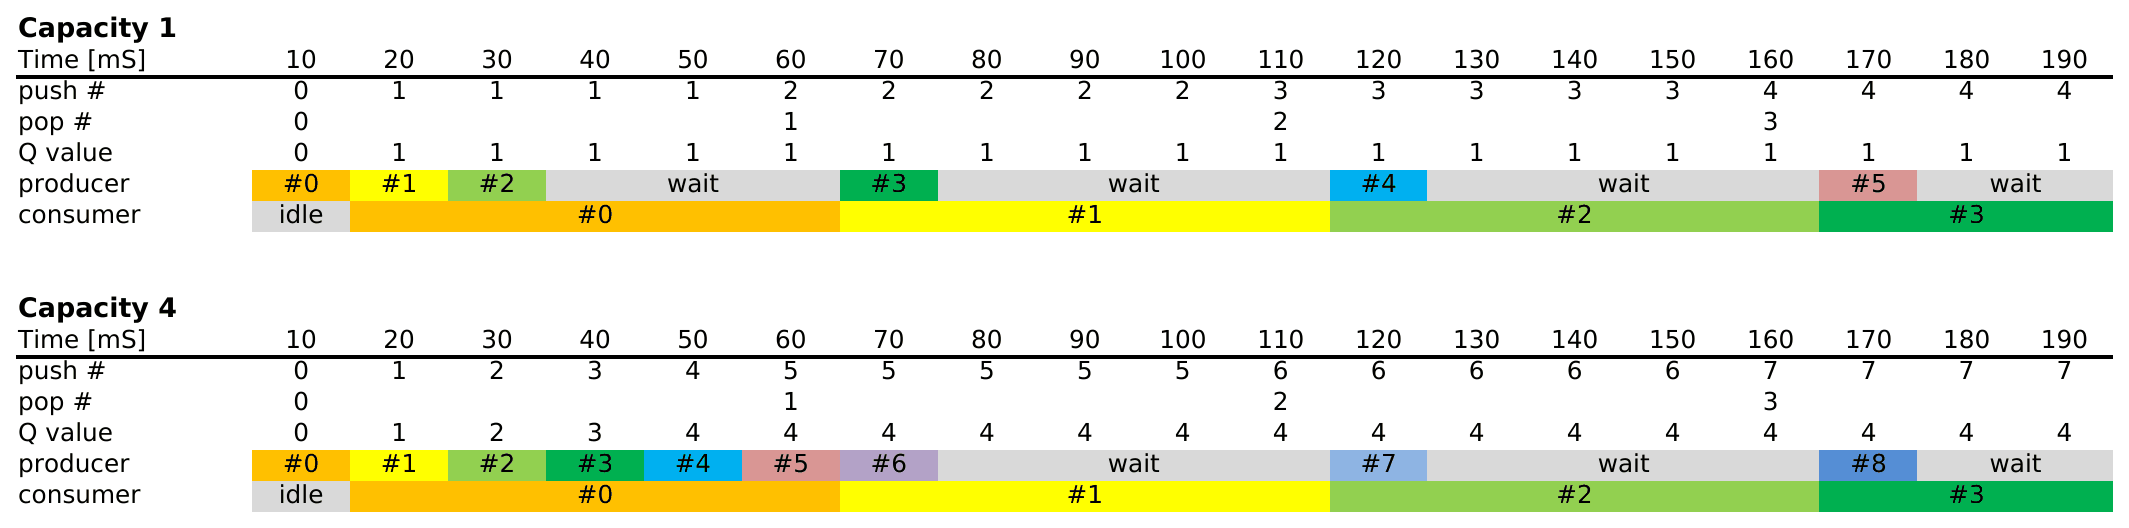

**`consumer` の帯を見比べてください。どちらも 10 / 60 / 110 / 160ms で切り替わり、同じ**です。
使う側は最初から最後まで途切れなく働いています。
使う側が 50ms に1個しかさばけない以上そこは動かないので、**FPS は変わりません。**

そして **`producer` の帯はほとんどが灰色の `wait`** です。作る側は 10ms で1個作れるのに、
キューが満杯で置き場所がなく、ずっと待たされています。

違うのは `Q value` の行と、**データがキューに並んでいた時間**だけです。

```
              #1    #2    #3    #4
容量1        40ms  50ms  50ms  50ms
容量4        40ms  80ms 120ms 160ms      ← 後ろに並んだものほど長く待つ
```

作る側が最初に `wait` に入るのは、容量1 なら 30ms、容量4 なら 60ms。
そこから先は **50ms に1個しか進めません**（使う側が1個取り出して、初めて1個入れられるため）。
容量を増やしても「先に作って置いておける個数」が増えるだけで、**使う側は1ミリも速くなりません。**

### 結果 ―― 【B】でこぼこがあると、容量1は遅い

```
【B】作る側 ふだん 10ms、5個に1回 90ms（平均26ms）、使う側 30ms/個 ―― 理想は 33.3 FPS
 capacity        FPS  peak(個) idle(ms) delay(ms)
        1       27.0         1       371        32
        2       33.0         2        10        38
        4       33.0         4        10        85
        8       33.0         8        10       131
       32       33.0        10        10       134
```

**容量1では 27.0 FPS。理想の 33.3 FPS に届いていません。**
`idle` が 371ms ―― 使う側がそれだけ**手待ち**していました。

#### 時刻を追って見る（【B】：作る側 ふだん 10ms、5個に1回だけ 90ms、使う側 30ms/個）

図の見かたは【A】と同じです。**`producer` の行に注目**してください。

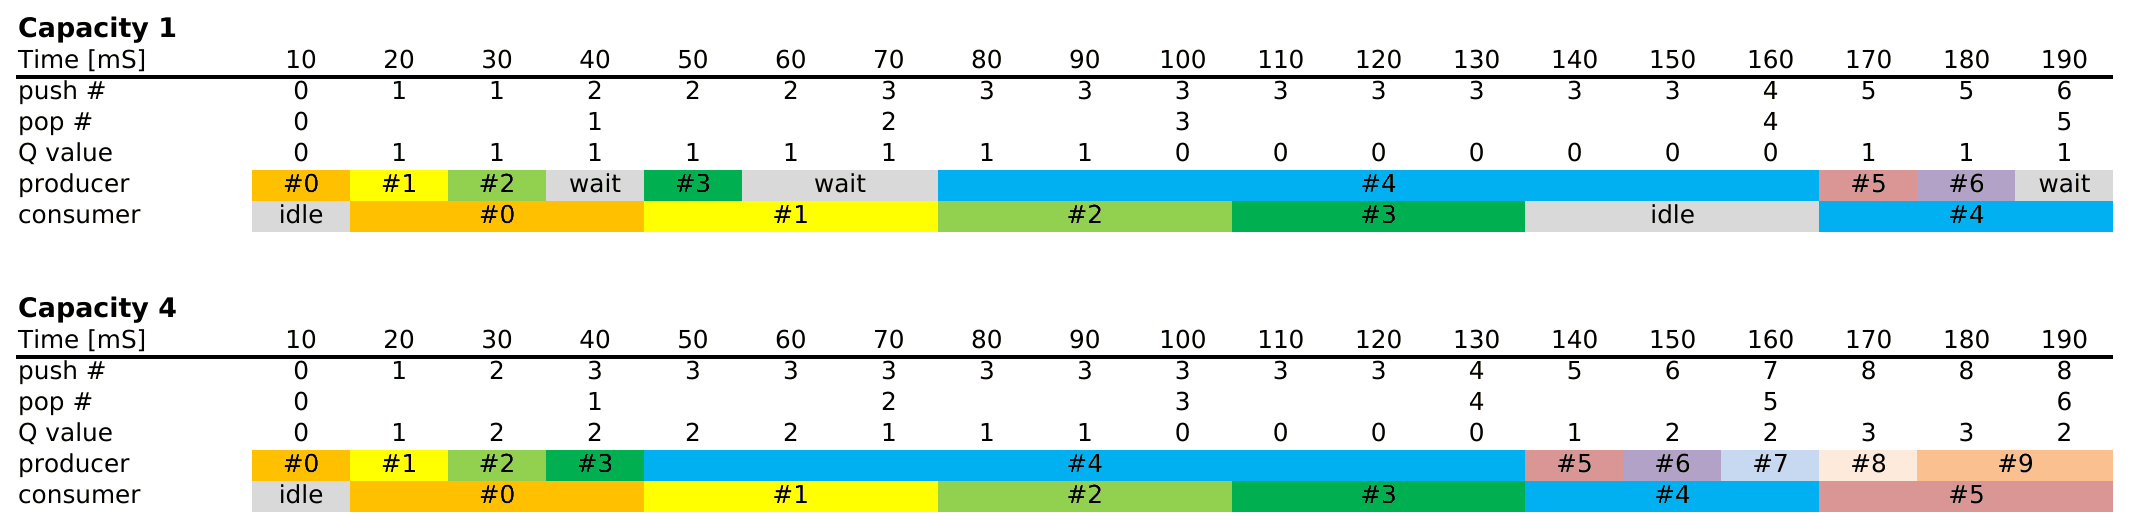

**`consumer` の行に、容量1 だけ灰色の `idle` が入っています。**
順に読むと、こうなっています。

**① `push #` が途中で止まるのはなぜか。**
`producer` の行を見ると、その区間は**長い `#4` の帯**になっています。
これは満杯で止まっているのではなく、**90ms かかる1個を作っている最中**です。
その間は当然 `push #` の値も動きません。

- **容量1** … `#4` を作りはじめるのが **70ms**（それまでは満杯で `wait` だった）⇒ 完成は **160ms**
- **容量4** … 4個先に置けるので、`#4` を作りはじめるのが **40ms** ⇒ 完成は **130ms**

**② `idle` が `#3` の終わりから始まるのはなぜか。**
`Q value` の行を見てください。容量1 では **100ms でキューが空（0）になり、そのまま 0 が続きます。**
使う側は `#3` を 130ms で出し終えますが、次の `#4` が届くのは 160ms。
**その 30ms が手待ちです。**

容量4 では、使う側が手を空ける 130ms に `#4` がちょうど届くので、手待ちが出ません。
つまり違いは **作る側が「90ms の1個」に取りかかれた時刻**（70ms か 40ms か）の一点だけです。

**③ 作る側の `wait` も減っています。**
容量1 では `#4` に取りかかる前に2回も `wait` が入っていますが、
容量4 では**この範囲に `wait` が1つもありません。**
容量に余裕があると、**待たされるのは使う側だけでなく、作る側も減ります。**
【A】との違いはここです（【A】はどちらの容量でも作る側が `wait` だらけでした）。

> **容量とは、段どうしの「でこぼこ」を吸収するクッションである。**

そして容量2で `idle` は 10ms まで落ち、**そこから先は 4 でも 32 でも FPS は同じ**です。
増えるのは遅れとメモリだけ。

### 容量の決め方

**横に並んでいるのは「キューの容量」**です（左が小さく、右へ行くほど大きい）。

```
                    ← キューの容量 →
          小さすぎる         ちょうどよい        大きすぎる
FPS       低い（手待ち）  →   理想に到達    →    理想のまま（変わらない）
delay     小さい          →   小さい        →    どんどん増える
memory    小さい          →   小さい        →    どんどん増える
```

**「FPS が理想に届く、いちばん小さい容量」が答え**です（この例では 2）。

目安は次の式です。使う側は「いま処理中の1個」と「キューに並んでいる `容量` 個」で
**`(容量 + 1) × 1個の処理時間`** のあいだ食いつなげます。これが遅れより短いと手待ちが出ます。

```
容量 ≒ 前の段が一時的に遅れる最大の時間 ÷ 次の段が1個を処理する時間 − 1
```

【B】なら `90 ÷ 30 − 1 = 2`。実測でちょうど 2 から理想に届いており、
図の手待ち 30ms も `90 −（1+1）× 30 = 30ms` と一致します。

> **でこぼこが小さければ、容量1でも手待ちは出ません。**
> 上の例で遅れが 60ms なら `(1+1) × 30 = 60ms` で足りてしまい、
> **容量を増やしても何も良くなりません。** 容量が効くのは、遅れがこれを超えるときだけです。

- 正確に計算する必要はありません。**1 から増やして、FPS が上がらなくなったら止める**
- **「遅いから容量を増やす」はたいてい間違い。** 効くのは `idle` が大きいときだけです
- 迷ったら**大きすぎるより小さすぎるほうがまし**（小さすぎは測れば分かる／大きすぎは気づきにくい）

## 3-2. 上限は2つある

容量が決まったら、次は**段の分け方と人数**です。ここで効いてくる上限が2つあります。

```
上限A = 1000ms ÷ 一番遅い段の時間(ms)　[FPS]  
上限B = 1000ms ÷ (データ１つの処理に CPU が使われた時間*¹ ÷ 速度倍率*²) [FPS]  
```
*1) パイプラインのデータ1つ（画像1枚）を処理完了するためにCPUが使われる時間 [mS]、外部（ディスク・アクセラレータ・画面）の返事待ちや、
  キューの順番待ちは含めない。  
*2) CPUコア数によってどれくらい速度が速くなるか。  
1)2)共に実測するのが望ましい。  

**実測FPS は2つの小さいほうを超えられません。**
- **上限A は流れ作業から導出。** 全体の速さは一番遅い係の速さです（演習1のボトルネック）。**段の切り方と、各段の人数を変えれば動きます。** 一番遅い段を2人にすれば、その段は実質半分の時間になり、上限A は上がります。

- **上限B はマシンの性能で決まる。** CPU を使う場所が足りなければ、それ以上は流せません。**人を何人並べても上限B は動きません。** 分母も分子も、スレッドの本数とは無関係だからです。

> **人を増やして減るのは「外部を待っている時間」であって、「計算量」ではない。**

### 実際にどうなるかは、測らないと分からない

- **段に分けても、段の数の倍にはならない。** 得られる倍率は
  「1個の合計時間 ÷ 一番遅い段の時間」までです
- **一番遅い段の人を増やせば上限A は上がる。** ただし上限B に届いたところで止まります
- **効いていない上限を上げても、何も起きません。** スレッドが増えるぶん、
  切り替えの手間だけが増えて**遅くなることさえあります**
- **速くすると、レイテンシと順序は悪くなります。**
  1個あたりの遅れは増え、人を増やせばデータの順番も入れ替わります
  （これは**バグではありません**。フレームに番号を持たせ、出口で並べ直すのが定石です）

そして、**上限B に出てくる「速度倍率」は、数えても分かりません。**

`hardware_concurrency()` が返すのは **OS から見えるスレッドの数**であって、
**同時に計算できる回路の数ではありません**（演習1-3 で見たとおりです）。
「2」と答える環境で、実際の速度倍率は **1.1倍程度**しかない、ということが起こります
（Colab の標準環境がそうです ―― 論理CPU は2つですが、**物理コアは1個**）。

> **これは倍率であって、コアの数ではありません。**
> コアの数は整数ですが、倍率は割り算の答えなので **1.1 のような値になります**
> （なぜそうなるかは**発展課題3-2**）。

**同じ計算を1本で回したときと、全部同時に回したときの速度比を実測する**しかありません。

> **数えるのではなく、測る。**

**その測り方は、発展課題3 の最後（付録）に置いてあります。**
同じ計算を1本・2本・3本・4本でやって時間を比べるだけの短いプログラムで、
自分のマシンの速度倍率がそのまま出ます。

> 🧩 **発展課題3-1・3-2** に、段の分け方と人数を変えて2つの上限を実測するプログラム、
> **付録**に速度倍率そのものを測るプログラムがあります。

## まとめ

- **キューの容量**は、段どうしの「でこぼこ」を吸収するクッション。
  **FPS が理想に届く、いちばん小さい値**にする。大きくしても速くならず、遅れとメモリが増えるだけ
- **上限は2つある。** 上限A（一番遅い段）と 上限B（マシンの計算力）。
  **実測FPS は、小さいほうを超えられない**
- **効いていない上限を上げる改造は、良くて無駄、悪ければ損**
- 速くすると、**レイテンシと順序は悪くなる。** FPS だけを見て判断しない
- `hardware_concurrency()` の値は当てにならない。**数えるのではなく、測る**

**次は演習4** ―― その「測る」を、壊さずにやる方法です。

> 🧩 発展課題は `adv03_pipeline.ipynb`（段に分けるとどれだけ速くなるか、人を増やすとどこで止まるか、
> キューの長さでボトルネックを当てる）。